# Hafta 9: Çoklu Dizi Hizalama ve Filogenetik Ağaçlar

**Biyoenformatiğe Giriş (Python & Biopython)**

**Bu haftanın hedefleri**
1. Çoklu dizi hizalamanın (MSA) amacını, ilerlemeli (progressive) yaklaşımı ve SP skorunu kavramak.
2. `AlignIO` ile MSA okumak/yazmak; konsensüs ve korunmuşluk (Shannon entropisi) hesaplamak.
3. Evrimsel uzaklıkları (p-uzaklığı, Jukes–Cantor) hesaplamak.
4. UPGMA ve Komşu Birleştirme (NJ) ile ağaç kurmak, `Bio.Phylo` ile çizmek, bootstrap desteğini hesaplamak ve gerçek ağaçla karşılaştırmak.

**Veri:** `protein_ailesi_hizali.aln` (Clustal), `filogeni_hizali.fasta` (bilinen bir ağaç boyunca simüle edilmiş 8 DNA dizisi), `gercek_agac.nwk`

> **Kullanım:** Colab'da *Çalışma zamanı → Tümünü çalıştır* ile tüm hücreleri sırayla çalıştırabilirsiniz. Alıştırmaların çözümleri notebook'un sonundadır; önce kendiniz deneyin.

In [1]:
# Colab'da gerekli kütüphaneleri kur (yalnızca ilk çalıştırmada birkaç saniye sürer)
!pip -q install biopython 
import Bio
print('Biopython sürümü:', Bio.__version__)

Biopython sürümü: 1.88


In [2]:
# ---------------- VERİ SETİNİ HAZIRLA ----------------
# Veri dosyaları ders paketindeki 'veri' klasöründe de mevcuttur.
# İsterseniz Colab'ın sol panelinden 'veri' klasörü oluşturup dosyaları yükleyebilirsiniz;
# dosya bulunamazsa aşağıdaki fonksiyon(lar) AYNI veriyi (sabit tohum) yeniden üretir.
import os

def veri_uret_protein_ailesi(klasor="veri"):
    """protein_ailesi.fasta (hizasız), protein_ailesi_hizali.aln (gerçek MSA, Clustal)."""
    import os, random
    from Bio.Seq import Seq
    from Bio.SeqRecord import SeqRecord
    from Bio.Align import MultipleSeqAlignment
    from Bio import SeqIO, AlignIO
    os.makedirs(klasor, exist_ok=True)
    rng = random.Random(2026)
    aa = "ACDEFGHIKLMNPQRSTVWY"
    frek = [8.3, 1.4, 5.5, 6.8, 3.9, 7.1, 2.3, 5.9, 5.8, 9.7, 2.4, 4.1, 4.7, 3.9, 5.4, 6.6, 5.3, 6.9, 1.1, 2.9]
    # Yer değiştirme olasılıkları BLOSUM62'den türetilir: P(b|a) ∝ p_b * 2^(s(a,b)/2)
    from Bio.Align import substitution_matrices
    B62 = substitution_matrices.load("BLOSUM62")
    gecis = {a: [0 if b == a else frek[j] * 2 ** (B62[a][b] / 2) for j, b in enumerate(aa)] for a in aa}
    L = 160
    ata = ["M"] + rng.choices(aa, weights=frek, k=L - 1)
    korunmus = set(rng.sample(range(1, L), 35)) | {0}

    def evrim(dizi, t):
        yeni = list(dizi)
        for i in range(len(yeni)):
            if yeni[i] == "-" or i in korunmus:
                continue
            if rng.random() < t:
                yeni[i] = rng.choices(aa, weights=gecis[yeni[i]])[0]
        if rng.random() < t * 2.5:                      # delesyon olayı
            u = rng.randint(1, 5)
            b = rng.randint(5, L - u - 5)
            if not any(k in korunmus for k in range(b, b + u)):
                for k in range(b, b + u):
                    yeni[k] = "-"
        return yeni

    # ((A1,A2),(A3,(A4,A5))) , ((B1,B2),B3)
    kA = evrim(ata, 0.15); kB = evrim(ata, 0.25)
    kA1 = evrim(kA, 0.08); kA2 = evrim(kA, 0.12)
    diziler = {
        "protA1": evrim(kA1, 0.05), "protA2": evrim(kA1, 0.06),
        "protA3": evrim(kA2, 0.10), "protA4": evrim(evrim(kA2, 0.05), 0.05),
        "protA5": evrim(evrim(kA2, 0.05), 0.07),
        "protB1": evrim(kB, 0.08), "protB2": evrim(kB, 0.10), "protB3": evrim(kB, 0.20),
    }
    hizali = MultipleSeqAlignment([SeqRecord(Seq("".join(v)), id=k) for k, v in diziler.items()])
    AlignIO.write(hizali, os.path.join(klasor, "protein_ailesi_hizali.aln"), "clustal")
    kayitlar = [SeqRecord(Seq("".join(v).replace("-", "")), id=k, description="sentetik protein ailesi uyesi")
                for k, v in diziler.items()]
    ilgisiz = "M" + "".join(rng.choices(aa, weights=frek, k=149))
    kayitlar.append(SeqRecord(Seq(ilgisiz), id="ilgisiz1", description="aileyle akraba olmayan rastgele protein"))
    SeqIO.write(kayitlar, os.path.join(klasor, "protein_ailesi.fasta"), "fasta")


def veri_uret_filogeni(klasor="veri"):
    """filogeni_hizali.fasta (JC69 ile ağaç boyunca simüle), gercek_agac.nwk"""
    import os, random, math
    os.makedirs(klasor, exist_ok=True)
    rng = random.Random(5)
    newick = ("((((Tur_1:0.04,Tur_2:0.04):0.08,Tur_3:0.12):0.10,(Tur_4:0.09,Tur_5:0.09):0.13):0.08,"
              "((Tur_6:0.07,Tur_7:0.07):0.11,Tur_8:0.18):0.12);")
    # küçük bir newick ayrıştırıcı
    def ayristir(s):
        s = s.strip().rstrip(";")
        def dugum(i):
            if s[i] == "(":
                cocuklar = []
                i += 1
                while True:
                    c, i = dugum(i)
                    cocuklar.append(c)
                    if s[i] == ",":
                        i += 1
                        continue
                    i += 1  # ')'
                    break
                ad = ""
            else:
                cocuklar, ad = [], ""
                while s[i] not in ":,)":
                    ad += s[i]; i += 1
            uz = 0.0
            if i < len(s) and s[i] == ":":
                i += 1; j = i
                while i < len(s) and s[i] not in ",)":
                    i += 1
                uz = float(s[j:i])
            return {"ad": ad, "uz": uz, "c": cocuklar}, i
        return dugum(0)[0]
    kok = ayristir(newick)
    L = 800
    kok_dizi = [rng.choice("ACGT") for _ in range(L)]
    sonuc = {}
    def in_(d, dizi):
        p = 0.75 * (1 - math.exp(-4 * d["uz"] / 3))
        yeni = [rng.choice([x for x in "ACGT" if x != b]) if rng.random() < p else b for b in dizi]
        if not d["c"]:
            sonuc[d["ad"]] = "".join(yeni)
        for c in d["c"]:
            in_(c, yeni)
    in_(kok, kok_dizi)
    with open(os.path.join(klasor, "filogeni_hizali.fasta"), "w") as f:
        for k in sorted(sonuc):
            f.write(f">{k}\n" + "\n".join(sonuc[k][i:i+80] for i in range(0, L, 80)) + "\n")
    with open(os.path.join(klasor, "gercek_agac.nwk"), "w") as f:
        f.write(newick + "\n")


if not os.path.exists('veri/filogeni_hizali.fasta'):
    veri_uret_protein_ailesi()
    veri_uret_filogeni()
print('veri klasörü:', sorted(os.listdir('veri')))


veri klasörü: ['1A8O.pdb', 'filogeni_hizali.fasta', 'gercek_agac.nwk', 'protein_ailesi.fasta', 'protein_ailesi_hizali.aln']


## 1. Çoklu dizi hizalama (MSA)
Üç veya daha fazla diziyi aynı anda hizalamak; korunmuş bölgeleri, fonksiyonel kalıntıları ve evrimsel ilişkileri ortaya çıkarır.

* Kesin dinamik programlama *N* dizi için $O(L^N)$ → pratikte imkânsız (NP-zor).
* **İlerlemeli hizalama** (Clustal, MAFFT, MUSCLE): (1) tüm ikili uzaklıkları hesapla → (2) kılavuz ağaç (guide tree) kur →
  (3) ağacın yapraklarından köküne doğru en benzer dizileri/profilleri sırayla hizala.
* Dezavantaj: "bir kez boşluk, hep boşluk" — erken yapılan hata düzeltilemez (iteratif iyileştirme bunu azaltır).

### SP (sum-of-pairs) skoru — sayısal örnek
Bir sütundaki tüm dizi çiftlerinin skorları toplanır. Eşleşme +1, uyumsuzluk −1, harf–boşluk −2, boşluk–boşluk 0.

Sütun: `A, A, C, -` → çiftler: (A,A)=+1, (A,C)=−1, (A,−)=−2, (A,C)=−1, (A,−)=−2, (C,−)=−2 → **SP = −7**.

In [3]:
from itertools import combinations

def sp_sutun(sutun, e=1, u=-1, g=-2):
    toplam = 0
    for a, b in combinations(sutun, 2):
        if a == "-" and b == "-":
            continue
        toplam += g if "-" in (a, b) else (e if a == b else u)
    return toplam

print("SP(A,A,C,-) =", sp_sutun("AAC-"))
print("SP(A,A,A,A) =", sp_sutun("AAAA"), "| SP(A,C,G,T) =", sp_sutun("ACGT"))

SP(A,A,C,-) = -7
SP(A,A,A,A) = 6 | SP(A,C,G,T) = -6


In [4]:
from Bio import AlignIO, SeqIO
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from collections import Counter

msa = AlignIO.read("veri/protein_ailesi_hizali.aln", "clustal")
print(msa)
print("\nDizi sayısı:", len(msa), "| hizalama uzunluğu:", msa.get_alignment_length())
print("İlk 3 dizinin 20-60. sütunları:")
print(msa[:3, 20:60])

Alignment with 8 rows and 160 columns
MDLLTDFNLSLRRRMSNDSKSQQEHDVSYVAYLKKTQMAQIKIM...IRA protA1
MDLLTDFNLSLRRRMFNDSKSQQEHDVSYLAYLKKTQMAQIKIM...IRA protA2
MGLLTSFRLSRRRRMFNDSKSQQEHDVSYLAHLSKTQMAQIEIG...IRA protA3
MGLLTDFKLSRRRRMFNDSKSQQEHDVSYLPHLSKTQMIQIKIG...IRA protA4
MGLLTDFKLSRRRRVLNESKSQQEHEASWLAHLSKTQMAQIKMG...IRA protA5
MNLITDFNLSLSRRVFNESKSQQKDQVDYLAHLGKIQMAKIRIM...IRA protB1
MYDITDFNLSLMRRVFNDSKSQQKGQVNYLAQLGKTQLAKIRIM...ISA protB2
MLLITDFNLSLMRRVFNDSKSQQ---VDYLAHLGKTQMAKIRIT...IRA protB3

Dizi sayısı: 8 | hizalama uzunluğu: 160
İlk 3 dizinin 20-60. sütunları:
Alignment with 3 rows and 40 columns
SQQEHDVSYVAYLKKTQMAQIKIMLDLRNLVFRVIAAFDA protA1
SQQEHDVSYLAYLKKTQMAQIKIMLDLRNLVFRVIAAFDA protA2
SQQEHDVSYLAHLSKTQMAQIEIGLDLRNLVFRVIAAFDA protA3


In [5]:
# Farklı formatlarda kaydetme
AlignIO.write(msa, "aile.fasta", "fasta")
AlignIO.write(msa, "aile.phy", "phylip-relaxed")
AlignIO.write(msa, "aile.sto", "stockholm")
print(open("aile.phy").read()[:300])
print("Toplam SP skoru (ilk 50 sütun):", sum(sp_sutun(msa[:, j]) for j in range(50)))

 8 160
protA1  MDLLTDFNLS LRRRMSNDSK SQQEHDVSYV AYLKKTQMAQ IKIMLDLRNL
protA2  MDLLTDFNLS LRRRMFNDSK SQQEHDVSYL AYLKKTQMAQ IKIMLDLRNL
protA3  MGLLTSFRLS RRRRMFNDSK SQQEHDVSYL AHLSKTQMAQ IEIGLDLRNL
protA4  MGLLTDFKLS RRRRMFNDSK SQQEHDVSYL PHLSKTQMIQ IKIGLDLRNL
protA5  MGLLTDFKLS RRRRVLNESK SQQEHEASWL 
Toplam SP skoru (ilk 50 sütun): 593


## 2. Konsensüs ve korunmuşluk
Her sütun için **Shannon entropisi**: $H = -\sum_a p_a \log_2 p_a$. Tam korunmuş sütun: H = 0; 20 amino asidin eşit dağıldığı sütun: $\log_2 20 \approx 4.32$ bit.

**Sayısal örnek:** Sütun `L L L L I I V V` → p(L)=0.5, p(I)=0.25, p(V)=0.25 → $H = -(0.5\log_2 0.5 + 2\cdot0.25\log_2 0.25) = 0.5 + 1 = 1.5$ bit.

H(LLLLIIVV) = 1.5
Konsensüs: MGLLTDFNLSLRRRMFNDSKSQQEHDVSYLAHLSKTQMAQIKIMLDLRNLVFRVIAAFDAQGDTLLYVNKEVYLLPGSLL ...
Tam korunmuş sütun sayısı: 59 / 160


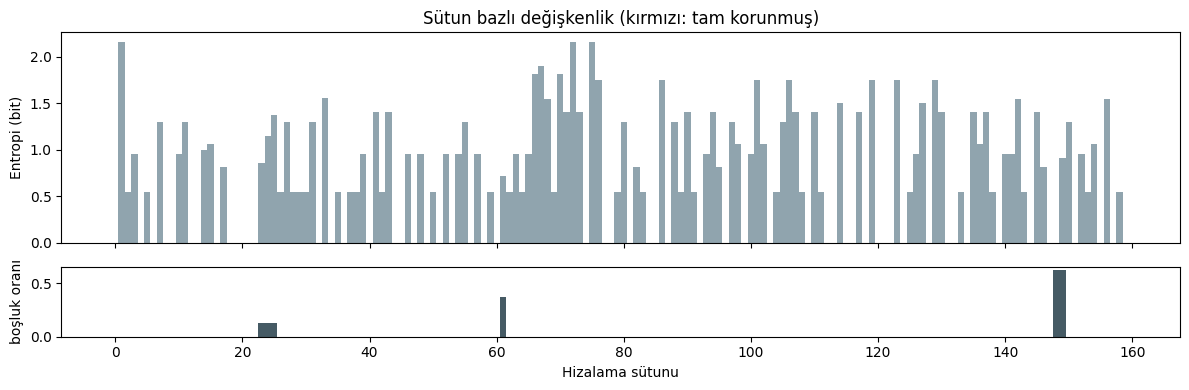

In [6]:
def entropi(sutun):
    harfler = [c for c in sutun if c != "-"]
    n = len(harfler)
    return -sum((k / n) * np.log2(k / n) for k in Counter(harfler).values())

print("H(LLLLIIVV) =", entropi("LLLLIIVV"))

L = msa.get_alignment_length()
H = np.array([entropi(msa[:, j]) for j in range(L)])
bosluk = np.array([msa[:, j].count("-") / len(msa) for j in range(L)])
konsensus = "".join(Counter(c for c in msa[:, j] if c != "-").most_common(1)[0][0] for j in range(L))
print("Konsensüs:", konsensus[:80], "...")
print("Tam korunmuş sütun sayısı:", int((H == 0).sum()), "/", L)

fig, ax = plt.subplots(2, 1, figsize=(12, 4), sharex=True, gridspec_kw={"height_ratios": [3, 1]})
ax[0].bar(range(L), H, color=np.where(H == 0, "#b71c1c", "#90a4ae"), width=1)
ax[0].set_ylabel("Entropi (bit)"); ax[0].set_title("Sütun bazlı değişkenlik (kırmızı: tam korunmuş)")
ax[1].bar(range(L), bosluk, color="#455a64", width=1); ax[1].set_ylabel("boşluk oranı"); ax[1].set_xlabel("Hizalama sütunu")
plt.tight_layout(); plt.show()

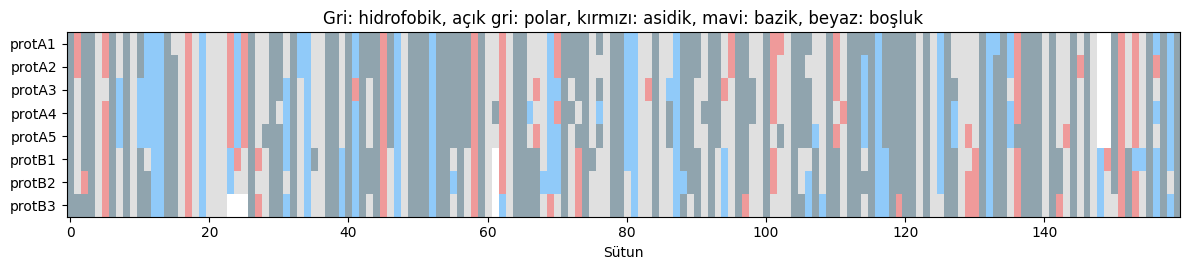

In [7]:
# Hizalamayı renkli bir ısı haritası olarak görselleştirme (amino asit sınıflarına göre)
sinif = {**{a: 0 for a in "AVLIMFWC"}, **{a: 1 for a in "STNQGPY"}, **{a: 2 for a in "DE"}, **{a: 3 for a in "KRH"}, "-": 4}
mat = np.array([[sinif.get(c, 4) for c in str(r.seq)] for r in msa])
from matplotlib.colors import ListedColormap
cmap = ListedColormap(["#90a4ae", "#e0e0e0", "#ef9a9a", "#90caf9", "white"])
plt.figure(figsize=(12, 2.8))
plt.imshow(mat, aspect="auto", cmap=cmap, interpolation="nearest")
plt.yticks(range(len(msa)), [r.id for r in msa]); plt.xlabel("Sütun")
plt.title("Gri: hidrofobik, açık gri: polar, kırmızı: asidik, mavi: bazik, beyaz: boşluk"); plt.tight_layout(); plt.show()

> **Gerçek araçlarla MSA (isteğe bağlı):** Colab'da `!apt-get -qq install clustalo` veya `!apt-get -qq install mafft` ile kurulup
`!clustalo -i protein_ailesi.fasta -o cikti.aln --outfmt=clu` şeklinde çalıştırılabilir. Sonuç `AlignIO.read` ile okunur.
Kendi dizilerimizin *gerçek* hizalamasını bildiğimiz için, bu araçların doğruluğunu karşılaştırmak iyi bir proje konusudur.

## 3. Evrimsel uzaklıklar
* **p-uzaklığı:** farklı sitelerin oranı, $p = \dfrac{\text{farklı}}{\text{karşılaştırılan}}$
* **Jukes–Cantor (JC69) düzeltmesi:** Aynı sitede birden fazla mutasyon (ör. A→G→A) görünmez; düzeltilmiş uzaklık:
  $d = -\dfrac{3}{4}\ln\left(1 - \dfrac{4}{3}p\right)$ (site başına beklenen yer değiştirme sayısı)

| p | 0.05 | 0.10 | 0.20 | 0.30 | 0.50 | 0.70 |
|---|---|---|---|---|---|---|
| d (JC) | 0.052 | 0.107 | 0.233 | 0.383 | 0.824 | 2.03 |

**Örnek:** 800 sitede 160 farklılık → p = 0.2 → $d = -0.75\ln(1-0.2667) = -0.75\ln(0.7333) = 0.233$.
p → 0.75 iken d → ∞ (doygunluk: rastgele DNA dizileri %25 özdeştir).

p=0.05 -> d=0.052
p=0.10 -> d=0.107
p=0.20 -> d=0.233
p=0.30 -> d=0.383
p=0.50 -> d=0.824
p=0.70 -> d=2.031


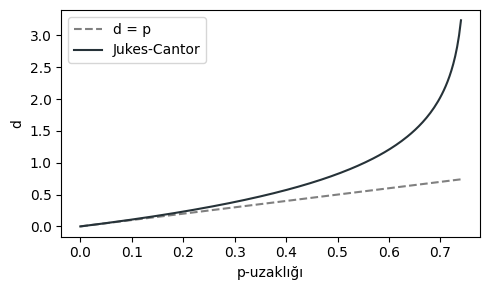

In [8]:
def jc(p):
    return -0.75 * np.log(1 - 4 * p / 3)
for p in [0.05, 0.1, 0.2, 0.3, 0.5, 0.7]:
    print(f"p={p:.2f} -> d={jc(p):.3f}")

pp = np.linspace(0, 0.74, 200)
plt.figure(figsize=(5, 3)); plt.plot(pp, pp, "--", color="gray", label="d = p"); plt.plot(pp, jc(pp), color="#263238", label="Jukes-Cantor")
plt.xlabel("p-uzaklığı"); plt.ylabel("d"); plt.legend(); plt.tight_layout(); plt.show()

In [9]:
dna = AlignIO.read("veri/filogeni_hizali.fasta", "fasta")
isim = [r.id for r in dna]
n = len(dna)
P = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        a, b = str(dna[i].seq), str(dna[j].seq)
        P[i, j] = sum(x != y for x, y in zip(a, b)) / len(a)
D = np.abs(jc(P))          # np.abs: köşegendeki -0.0 değerlerini temizler
print("p-uzaklıkları:\n", pd.DataFrame(P, index=isim, columns=isim).round(3))
print("\nJC uzaklıkları:\n", pd.DataFrame(D, index=isim, columns=isim).round(3))

p-uzaklıkları:
        Tur_1  Tur_2  Tur_3  Tur_4  Tur_5  Tur_6  Tur_7  Tur_8
Tur_1  0.000  0.078  0.206  0.339  0.370  0.412  0.409  0.428
Tur_2  0.078  0.000  0.196  0.330  0.364  0.415  0.406  0.408
Tur_3  0.206  0.196  0.000  0.338  0.362  0.419  0.404  0.421
Tur_4  0.339  0.330  0.338  0.000  0.162  0.412  0.418  0.412
Tur_5  0.370  0.364  0.362  0.162  0.000  0.414  0.418  0.411
Tur_6  0.412  0.415  0.419  0.412  0.414  0.000  0.126  0.316
Tur_7  0.409  0.406  0.404  0.418  0.418  0.126  0.000  0.319
Tur_8  0.428  0.408  0.421  0.412  0.411  0.316  0.319  0.000

JC uzaklıkları:
        Tur_1  Tur_2  Tur_3  Tur_4  Tur_5  Tur_6  Tur_7  Tur_8
Tur_1  0.000  0.082  0.241  0.451  0.510  0.599  0.591  0.633
Tur_2  0.082  0.000  0.228  0.435  0.498  0.604  0.585  0.588
Tur_3  0.241  0.228  0.000  0.448  0.495  0.613  0.580  0.619
Tur_4  0.451  0.435  0.448  0.000  0.183  0.599  0.610  0.599
Tur_5  0.510  0.498  0.495  0.183  0.000  0.602  0.610  0.596
Tur_6  0.599  0.604  0.613  0.599  0

## 4. Ağaç kurma yöntemleri

| Yöntem | Tür | Varsayım | Karmaşıklık |
|---|---|---|---|
| UPGMA | Uzaklık, kümeleme | **Moleküler saat** (tüm soylarda eşit hız) → köklü, ultrametrik ağaç | $O(n^2)$–$O(n^3)$ |
| Komşu Birleştirme (NJ) | Uzaklık | Toplamsallık; hız sabitliği gerekmez → köksüz ağaç | $O(n^3)$ |
| Maksimum tutumluluk (parsimony) | Karakter | En az değişim | NP-zor (sezgisel) |
| Maksimum olabilirlik / Bayesçi | Model tabanlı | Açık evrim modeli | Çok yüksek |

### UPGMA — elle örnek
|   | A | B | C | D |
|---|---|---|---|---|
| A | 0 | 4 | 8 | 12 |
| B | 4 | 0 | 8 | 12 |
| C | 8 | 8 | 0 | 10 |
| D | 12 | 12 | 10 | 0 |

1. En küçük uzaklık d(A,B) = 4 → (AB) kümesi, yükseklik 4/2 = **2**.
2. Yeni uzaklıklar (küme boyutlarıyla ağırlıklı ortalama): d(AB,C) = (8+8)/2 = 8, d(AB,D) = (12+12)/2 = 12.
3. En küçük: d(AB,C) = 8 → ((AB)C), yükseklik **4**.
4. d((AB)C, D) = (2·12 + 1·10)/3 = **11.33** → kök yüksekliği **5.67**.

Newick: `(((A:2,B:2):2,C:4):1.67,D:5.67);`

> **Not:** Biopython'un `DistanceTreeConstructor().upgma()` fonksiyonu yeni uzaklığı iki kümenin **basit** ortalamasıyla hesaplar
(yani aslında **WPGMA**'dır: 4. adımda (12+10)/2 = 11). Aşağıda gerçek UPGMA'yı kendimiz yazıyoruz.

In [10]:
def upgma(D, isimler):
    D = D.astype(float).copy()
    kumeler = [{"ad": a, "boyut": 1, "yukseklik": 0.0} for a in isimler]
    adimlar = []
    while len(kumeler) > 1:
        n = len(kumeler)
        i, j = min(((i, j) for i in range(n) for j in range(i + 1, n)), key=lambda t: D[t])
        h = D[i, j] / 2
        ki, kj = kumeler[i], kumeler[j]
        yeni = {"ad": f"({ki['ad']}:{h - ki['yukseklik']:.3g},{kj['ad']}:{h - kj['yukseklik']:.3g})",
                "boyut": ki["boyut"] + kj["boyut"], "yukseklik": h}
        adimlar.append((ki["ad"], kj["ad"], round(D[i, j], 3), round(h, 3)))
        yeni_satir = (ki["boyut"] * D[i] + kj["boyut"] * D[j]) / yeni["boyut"]
        tut = [k for k in range(n) if k not in (i, j)]
        D2 = np.zeros((len(tut) + 1, len(tut) + 1))
        D2[:-1, :-1] = D[np.ix_(tut, tut)]
        D2[-1, :-1] = D2[:-1, -1] = yeni_satir[tut]
        D = D2
        kumeler = [kumeler[k] for k in tut] + [yeni]
    return kumeler[0]["ad"] + ";", adimlar

ornek = np.array([[0, 4, 8, 12], [4, 0, 8, 12], [8, 8, 0, 10], [12, 12, 10, 0]])
nwk, adimlar = upgma(ornek, list("ABCD"))
for a in adimlar:
    print("birleştir:", a[0], "+", a[1], "| uzaklık:", a[2], "| yükseklik:", a[3])
print(nwk)

birleştir: A + B | uzaklık: 4.0 | yükseklik: 2.0
birleştir: C + (A:2,B:2) | uzaklık: 8.0 | yükseklik: 4.0
birleştir: D + (C:4,(A:2,B:2):2) | uzaklık: 11.333 | yükseklik: 5.667
(D:5.67,(C:4,(A:2,B:2):2):1.67);


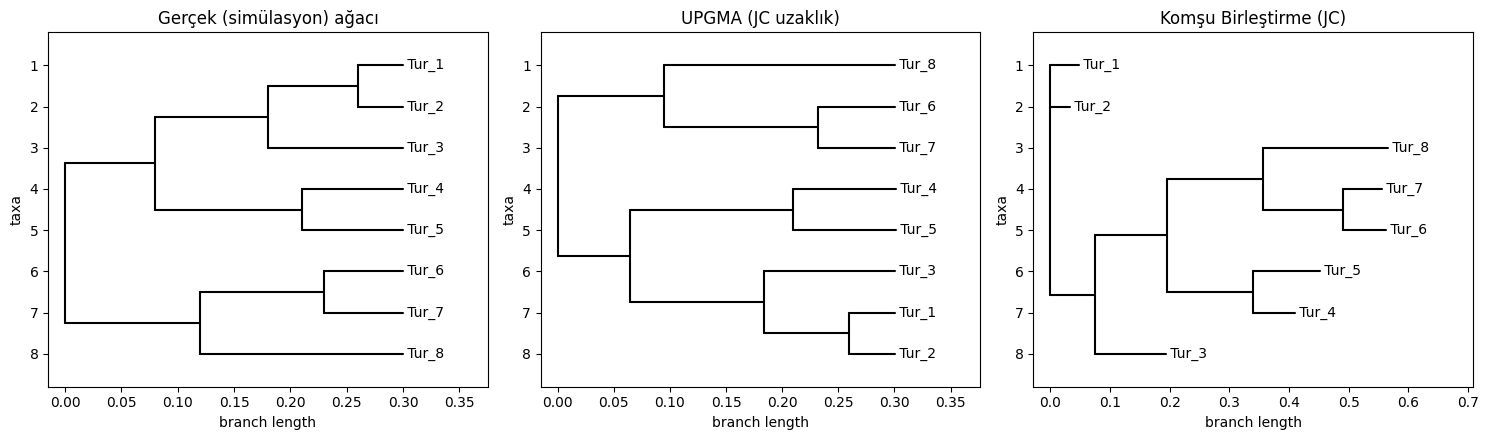

  _____ Tur_1
 |
 |___ Tur_2
 |
 |                                            __________________________ Tur_8
_|                        ___________________|
 |                       |                   |                 _______ Tur_7
 |                       |                   |________________|
 |         ______________|                                    |________ Tur_6
 |        |              |
 |        |              |                  _____________ Tur_5
 |________|              |_________________|
          |                                |________ Tur_4
          |
          |______________ Tur_3



In [11]:
from Bio import Phylo
from io import StringIO
from Bio.Phylo.TreeConstruction import DistanceMatrix, DistanceTreeConstructor

def dm_olustur(D, isimler):
    alt_ucgen = [[float(D[i, j]) for j in range(i + 1)] for i in range(len(isimler))]
    return DistanceMatrix(isimler, alt_ucgen)

dm = dm_olustur(D, isim)
kurucu = DistanceTreeConstructor()
agac_nj = kurucu.nj(dm)
agac_upgma = Phylo.read(StringIO(upgma(D, isim)[0]), "newick")
gercek_agac = Phylo.read("veri/gercek_agac.nwk", "newick")

fig, ax = plt.subplots(1, 3, figsize=(15, 4.5))
for a, (t, baslik) in zip(ax, [(gercek_agac, "Gerçek (simülasyon) ağacı"), (agac_upgma, "UPGMA (JC uzaklık)"), (agac_nj, "Komşu Birleştirme (JC)")]):
    Phylo.draw(t, axes=a, do_show=False, label_func=lambda c: c.name if c.is_terminal() else "")
    a.set_title(baslik)
plt.tight_layout(); plt.show()
Phylo.draw_ascii(agac_nj)

## 5. Ağaçları karşılaştırmak: Robinson–Foulds uzaklığı
Her iç dal, yaprakları iki gruba ayırır (**bipartisyon**). RF uzaklığı = iki ağaçtan yalnızca birinde bulunan bipartisyon sayısı.
RF = 0 → topolojiler aynı.

In [12]:
def bipartisyonlar(agac):
    tum = frozenset(t.name for t in agac.get_terminals())
    kume = set()
    for c in agac.find_clades():
        yap = frozenset(t.name for t in c.get_terminals())
        if 1 < len(yap) < len(tum) - 1:
            kume.add(min(yap, tum - yap, key=lambda s: sorted(s)))   # köksüz: iki yarıdan birini seç
    return kume

def rf(a1, a2):
    b1, b2 = bipartisyonlar(a1), bipartisyonlar(a2)
    return len(b1 ^ b2)

print("RF(gerçek, UPGMA) =", rf(gercek_agac, agac_upgma))
print("RF(gerçek, NJ)    =", rf(gercek_agac, agac_nj))

RF(gerçek, UPGMA) = 0
RF(gerçek, NJ)    = 0


## 6. Bootstrap: dallar ne kadar güvenilir?
Hizalamanın sütunları **iadeli** yeniden örneklenir, her örnek için ağaç kurulur; bir dalın kaç ağaçta tekrar ettiği yüzdesi = **bootstrap desteği**.
Genelde ≥ %70 güvenilir kabul edilir.

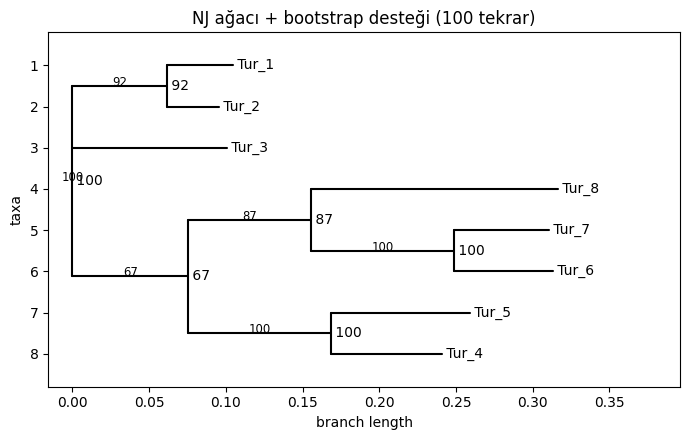

In [13]:
from Bio.Phylo.TreeConstruction import DistanceCalculator
from Bio.Phylo.Consensus import bootstrap_trees, get_support, majority_consensus

hesap = DistanceCalculator("identity")                # 1 - özdeşlik = p-uzaklığı
nj_kurucu = DistanceTreeConstructor(hesap, "nj")
agaclar = list(bootstrap_trees(dna, 100, nj_kurucu))
temel = nj_kurucu.build_tree(dna)
destekli = get_support(temel, agaclar)
for c in destekli.get_nonterminals():
    if c.confidence is not None:
        c.name = f"{c.confidence:.0f}"
fig, ax = plt.subplots(figsize=(7, 4.5))
Phylo.draw(destekli, axes=ax, do_show=False)
ax.set_title("NJ ağacı + bootstrap desteği (100 tekrar)"); plt.tight_layout(); plt.show()

## 7. Protein ailesinin ağacı

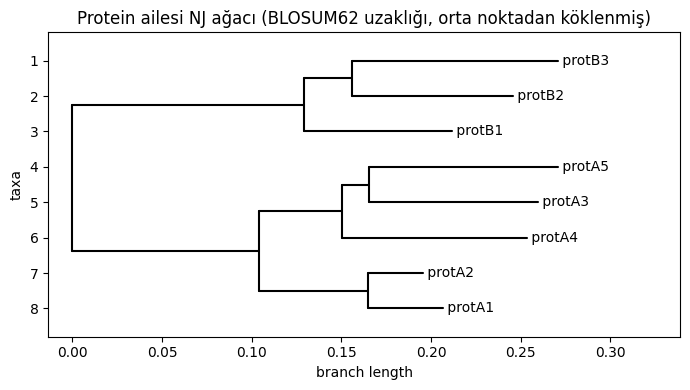

In [14]:
hesap_p = DistanceCalculator("blosum62")
dm_p = hesap_p.get_distance(msa)
agac_p = DistanceTreeConstructor().nj(dm_p)
agac_p.root_at_midpoint()
fig, ax = plt.subplots(figsize=(7, 4))
Phylo.draw(agac_p, axes=ax, do_show=False, label_func=lambda c: c.name if c.is_terminal() else "")
ax.set_title("Protein ailesi NJ ağacı (BLOSUM62 uzaklığı, orta noktadan köklenmiş)"); plt.tight_layout(); plt.show()

## 8. Alıştırmalar
1. `ACGT-`, `ACGTT`, `ACCTT` üç dizisinin SP skorunu (eşleşme +1, uyumsuzluk −1, harf-boşluk −2) sütun sütun hesaplayın.
2. 1000 sitede 300 farklılık gözlenen iki dizi için p ve JC uzaklığını bulun. p = 0.74 olsaydı ne olurdu?
3. Aşağıdaki matrisi elle UPGMA ile ağaca dönüştürün; `upgma` fonksiyonumuz ve Biopython'un WPGMA sonucuyla karşılaştırın:
   d(A,B)=2, d(A,C)=6, d(A,D)=10, d(B,C)=6, d(B,D)=10, d(C,D)=7.
4. Simülasyon verisinde yalnızca ilk 100 sütunu kullanarak NJ ağacı kurun. RF uzaklığı ve bootstrap destekleri nasıl değişti? Neden?
5. p-uzaklığı yerine JC uzaklığı kullanmak NJ topolojisini değiştirdi mi? Dal uzunluklarını karşılaştırın.

---
## Çözümler

In [15]:
# 1
seqs = ["ACGT-", "ACGTT", "ACCTT"]
sutunlar = ["".join(s[j] for s in seqs) for j in range(5)]
print("1)", [(s, sp_sutun(s)) for s in sutunlar], "toplam =", sum(sp_sutun(s) for s in sutunlar))
# 2
print(f"2) p=0.3 -> d={jc(0.3):.3f};  p=0.74 -> d={jc(0.74):.2f} (doygunluğa yakın, güvenilmez)")
# 3
M3 = np.array([[0, 2, 6, 10], [2, 0, 6, 10], [6, 6, 0, 7], [10, 10, 7, 0]])
print("3) UPGMA:", upgma(M3, list("ABCD"))[0])
t3 = DistanceTreeConstructor().upgma(dm_olustur(M3, list("ABCD")))
print("   Biopython (WPGMA):"); Phylo.draw_ascii(t3)
# 4
kisa = dna[:, :100]
t4 = nj_kurucu.build_tree(kisa)
print("4) RF(gerçek, NJ-100 sütun) =", rf(gercek_agac, t4), "(topoloji doğru olsa bile destekler düşer)")
d4 = get_support(t4, list(bootstrap_trees(kisa, 100, nj_kurucu)))
print("   destekler:", sorted(int(c.confidence) for c in d4.get_nonterminals() if c.confidence is not None))
# 5
t_p = DistanceTreeConstructor().nj(dm_olustur(P, isim))
print("5) RF(NJ-p, NJ-JC) =", rf(t_p, agac_nj), "| toplam dal uzunluğu p:", round(t_p.total_branch_length(), 3),
      "JC:", round(agac_nj.total_branch_length(), 3), "| gerçek:", round(gercek_agac.total_branch_length(), 3))

1) [('AAA', 3), ('CCC', 3), ('GGC', -1), ('TTT', 3), ('-TT', -3)] toplam = 5
2) p=0.3 -> d=0.383;  p=0.74 -> d=3.24 (doygunluğa yakın, güvenilmez)
3) UPGMA: (D:4.5,(C:3,(A:1,B:1):2):1.5);
   Biopython (WPGMA):
  ___________________________________________________________________________ D
_|
 |                      _____________________________________________________ C
 |_____________________|
                       |                                    _________________ B
                       |___________________________________|
                                                           |_________________ A

4) RF(gerçek, NJ-100 sütun) = 0 (topoloji doğru olsa bile destekler düşer)


   destekler: [76, 79, 94, 97, 98, 100]
5) RF(NJ-p, NJ-JC) = 0 | toplam dal uzunluğu p: 1.032 JC: 1.365 | gerçek: 1.32
